In [174]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


In [175]:
# Cargar datos para Train

portatiles = pd.read_csv(r'train.csv')

In [176]:
portatiles.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,697,705,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,435,442,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,735,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,864,875,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,1176,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


In [177]:
portatiles.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   laptop_ID         912 non-null    int64  
 2   Company           912 non-null    str    
 3   Product           912 non-null    str    
 4   TypeName          912 non-null    str    
 5   Inches            912 non-null    float64
 6   ScreenResolution  912 non-null    str    
 7   Cpu               912 non-null    str    
 8   Ram               912 non-null    str    
 9   Memory            912 non-null    str    
 10  Gpu               912 non-null    str    
 11  OpSys             912 non-null    str    
 12  Weight            912 non-null    str    
 13  Price_euros       912 non-null    float64
dtypes: float64(2), int64(2), str(10)
memory usage: 99.9 KB


In [178]:
# No hay nulos. 
# Feature engineering. 
# Empezamos por lo más fácil. Convertir a números el peso y la memoria RAm

In [179]:
portatiles ['Weight'] = portatiles ['Weight'].str.rstrip('kg')

In [180]:
portatiles ['Weight']= portatiles ['Weight'].astype (float)

In [181]:
portatiles['Ram'].unique()

<StringArray>
['4GB', '8GB', '16GB', '6GB', '12GB', '2GB', '24GB', '32GB', '64GB']
Length: 9, dtype: str

In [182]:
portatiles ['Ram'] = portatiles ['Ram'].str.rstrip('GB').astype (int)

In [183]:
portatiles.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   laptop_ID         912 non-null    int64  
 2   Company           912 non-null    str    
 3   Product           912 non-null    str    
 4   TypeName          912 non-null    str    
 5   Inches            912 non-null    float64
 6   ScreenResolution  912 non-null    str    
 7   Cpu               912 non-null    str    
 8   Ram               912 non-null    int64  
 9   Memory            912 non-null    str    
 10  Gpu               912 non-null    str    
 11  OpSys             912 non-null    str    
 12  Weight            912 non-null    float64
 13  Price_euros       912 non-null    float64
dtypes: float64(3), int64(3), str(8)
memory usage: 99.9 KB


In [184]:
# Hago un get_dummies para las marcas, lo veo relevante y no quiero meter un valor aleatorio
marcas = portatiles ['Company'].str.get_dummies()


In [185]:
portatiles = pd.concat([portatiles, marcas], axis=1)
portatiles = portatiles.drop(columns='Company')

In [186]:
#lo mismo para el tipo, además sólo hay 6
portatiles ['TypeName'].unique()

<StringArray>
['2 in 1 Convertible',             'Gaming',           'Notebook',
          'Ultrabook',            'Netbook',        'Workstation']
Length: 6, dtype: str

In [187]:
tipo = portatiles ['TypeName'].str.get_dummies()
portatiles = pd.concat([portatiles, tipo], axis=1)
portatiles = portatiles.drop(columns='TypeName')


In [188]:
portatiles['Cpu'].unique()

<StringArray>
[         'Intel Core M M3-6Y30 0.9GHz',
                'AMD Ryzen 1600 3.2GHz',
           'Intel Core i7 7500U 2.7GHz',
           'Intel Core i7 7660U 2.5GHz',
           'Intel Core i7 6500U 2.5GHz',
 'Intel Celeron Quad Core N3450 1.1GHz',
 'Intel Pentium Quad Core N4200 1.1GHz',
          'Intel Core i7 7700HQ 2.8GHz',
          'Intel Core i7 7820HK 2.9GHz',
           'Intel Core i5 6300U 2.4GHz',
 ...
          'Intel Core i7 6500U 2.50GHz',
 'Intel Pentium Quad Core N3700 1.6GHz',
                 'Intel Core i7 2.8GHz',
           'Intel Core i7 7500U 2.5GHz',
                 'Intel Core i7 2.9GHz',
            'AMD A6-Series 9220 2.9GHz',
          'Intel Core i7 7700HQ 2.7GHz',
                 'Intel Core i5 1.3GHz',
          'AMD A10-Series 9600P 2.4GHz',
              'AMD A6-Series 7310 2GHz']
Length: 102, dtype: str

In [189]:
# La velocidad del procesador está siempre al final, son y seguido de GHz - es string, pasar a float
portatiles['velocidad'] = portatiles['Cpu'].str.extract(r'(\d+(?:\.\d+)?)GHz').astype(float)

In [190]:
portatiles[portatiles ['velocidad'].isna()]

,id,laptop_ID,Product,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,...,Toshiba,Vero,Xiaomi,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation,velocidad


In [191]:
portatiles['velocidad']

0      0.9
1      3.2
2      2.7
3      2.5
4      2.5
      ... 
907    2.5
908    2.4
909    2.5
910    2.0
911    2.8
Name: velocidad, Length: 912, dtype: float64

In [192]:
portatiles ['Cpu'].str.replace(r'(\d+(?:\.\d+)?)GHz','',regex=True).unique()

<StringArray>
[         'Intel Core M M3-6Y30 ',                'AMD Ryzen 1600 ',
           'Intel Core i7 7500U ',           'Intel Core i7 7660U ',
           'Intel Core i7 6500U ', 'Intel Celeron Quad Core N3450 ',
 'Intel Pentium Quad Core N4200 ',          'Intel Core i7 7700HQ ',
          'Intel Core i7 7820HK ',           'Intel Core i5 6300U ',
           'Intel Core i5 7200U ',         'AMD A9-Series A9-9420 ',
           'Intel Core i3 7100U ',           'Intel Core i7 8550U ',
 'Intel Celeron Dual Core 3855U ',           'Intel Core i3 6006U ',
          'AMD A12-Series 9720P ',            'AMD E-Series 9000e ',
           'Intel Core i3 6100U ', 'Intel Celeron Dual Core N3060 ',
          'Intel Core i5 7300HQ ',           'Intel Core i5 8250U ',
                'AMD Ryzen 1700 ',           'Intel Core i7 6600U ',
           'Intel Core i5 6200U ',                 'Intel Core i5 ',
            'AMD A9-Series 9410 ',          'Intel Core i7 6820HK ',
           'Intel Co

In [193]:
# Me voy a quedar con la marca (Intel Amd) y el tipo
portatiles['cpu_marca'] = portatiles['Cpu'].str.split().str[:1].str.join(' ')

In [194]:
#me quedo con el tipo de cpu
gamas = ['Core i3', 'Core i5', 'Core i7', 'Core M', 'Celeron', 'Pentium', 'Ryzen', 'Atom', 'Xeon','A4_Series', 'A6-Series', 'A8-Series', 'A9-Series', 'A10-Series', 'A12-Series', 'E-Series']

#join une los elementos de una lista con el separador indicado. En regex | significa "o". 
patron = '|'.join(gamas)
#Los paréntesis () son de regex e indican el grupo de captura, que es lo que extract devuelve
portatiles['gama'] = portatiles['Cpu'].str.extract(f'({patron})')

In [195]:
# a ver cuantos nulos quedan
portatiles.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  912 non-null    int64  
 1   laptop_ID           912 non-null    int64  
 2   Product             912 non-null    str    
 3   Inches              912 non-null    float64
 4   ScreenResolution    912 non-null    str    
 5   Cpu                 912 non-null    str    
 6   Ram                 912 non-null    int64  
 7   Memory              912 non-null    str    
 8   Gpu                 912 non-null    str    
 9   OpSys               912 non-null    str    
 10  Weight              912 non-null    float64
 11  Price_euros         912 non-null    float64
 12  Acer                912 non-null    int64  
 13  Apple               912 non-null    int64  
 14  Asus                912 non-null    int64  
 15  Chuwi               912 non-null    int64  
 16  Dell               

In [196]:
portatiles.columns

Index(['id', 'laptop_ID', 'Product', 'Inches', 'ScreenResolution', 'Cpu',
       'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros', 'Acer',
       'Apple', 'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei',
       'LG', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung',
       'Toshiba', 'Vero', 'Xiaomi', '2 in 1 Convertible', 'Gaming', 'Netbook',
       'Notebook', 'Ultrabook', 'Workstation', 'velocidad', 'cpu_marca',
       'gama'],
      dtype='str')

In [197]:
portatiles = portatiles.drop(columns='Cpu')

In [198]:
tipos_cpu = portatiles ['gama'].str.get_dummies()

In [199]:
portatiles = pd.concat([portatiles, tipos_cpu], axis=1).reset_index(drop=True)

In [200]:
portatiles.columns

Index(['id', 'laptop_ID', 'Product', 'Inches', 'ScreenResolution', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros', 'Acer', 'Apple',
       'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG',
       'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba',
       'Vero', 'Xiaomi', '2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook',
       'Ultrabook', 'Workstation', 'velocidad', 'cpu_marca', 'gama',
       'A10-Series', 'A12-Series', 'A6-Series', 'A8-Series', 'A9-Series',
       'Atom', 'Celeron', 'Core M', 'Core i3', 'Core i5', 'Core i7',
       'E-Series', 'Pentium', 'Ryzen', 'Xeon'],
      dtype='str')

In [201]:
portatiles = portatiles.drop(columns='gama')

In [202]:
marca_cpu = portatiles ['cpu_marca'].str.get_dummies()

In [203]:
portatiles = pd.concat ([portatiles, marca_cpu],axis=1).reset_index(drop=True)

In [204]:
portatiles = portatiles.drop (columns='cpu_marca')

In [205]:
portatiles.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  912 non-null    int64  
 1   laptop_ID           912 non-null    int64  
 2   Product             912 non-null    str    
 3   Inches              912 non-null    float64
 4   ScreenResolution    912 non-null    str    
 5   Ram                 912 non-null    int64  
 6   Memory              912 non-null    str    
 7   Gpu                 912 non-null    str    
 8   OpSys               912 non-null    str    
 9   Weight              912 non-null    float64
 10  Price_euros         912 non-null    float64
 11  Acer                912 non-null    int64  
 12  Apple               912 non-null    int64  
 13  Asus                912 non-null    int64  
 14  Chuwi               912 non-null    int64  
 15  Dell                912 non-null    int64  
 16  Fujitsu            

In [206]:
#a ver qué pinta tienen los strings que quedan
portatiles[['Product','ScreenResolution','Memory','Gpu', 'OpSys']]


,Product,ScreenResolution,Memory,Gpu,OpSys
0,Chromebook Flip,Full HD / Touchscreen 1920x1080,64GB Flash Storage,Intel HD Graphics 515,Chrome OS
1,Rog Strix,Full HD 1920x1080,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10
2,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Full HD 1920x1080,1TB HDD,Intel HD Graphics 620,Windows 10
3,XPS 13,Quad HD+ / Touchscreen 3200x1800,512GB SSD,Intel Iris Plus Graphics 640,Windows 10
4,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Full HD 1920x1080,1.0TB Hybrid,Intel HD Graphics 520,Windows 7
...,...,...,...,...,...
907,Vostro 3568,1366x768,1TB HDD,AMD Radeon R5 M420,Windows 10
908,IdeaPad 310-15ABR,Full HD 1920x1080,1TB HDD,AMD Radeon R5 430,Windows 10
909,GL62M 7RD,Full HD 1920x1080,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10
910,110-15ACL (A6-7310/4GB/500GB/W10),1366x768,500GB HDD,AMD Radeon R4,Windows 10


In [207]:
portatiles ['Memory'].unique()

<StringArray>
[           '64GB Flash Storage',          '256GB SSD +  1TB HDD',
                       '1TB HDD',                     '512GB SSD',
                  '1.0TB Hybrid',                      '32GB SSD',
                     '500GB HDD',                     '256GB SSD',
          '128GB SSD +  1TB HDD',                     '128GB SSD',
            '32GB Flash Storage',           '128GB Flash Storage',
                     '180GB SSD',          '512GB SSD +  1TB HDD',
            '16GB Flash Storage',           '512GB Flash Storage',
                       '2TB HDD',          '256GB SSD +  2TB HDD',
        '512GB SSD +  256GB SSD',                       '1TB SSD',
        '256GB SSD +  256GB SSD',                  '508GB Hybrid',
           '256GB Flash Storage',                     '128GB HDD',
     '256GB SSD +  1.0TB Hybrid',        '512GB SSD +  512GB SSD',
          '128GB SSD +  2TB HDD', '64GB Flash Storage +  1TB HDD',
          '512GB SSD +  2TB HDD',               

In [208]:
#Hay mucha info en este campo. Después de curiosear un poco entiendo que lo más relevante (caro) es si tiene o no SSD
# Y por otra parte, la memoria total

In [209]:
# Esto es lo más fácil
portatiles['SSD'] = portatiles['Memory'].str.contains('SSD')

In [210]:
#Prueba a lo bruto. Separar por +

separar=portatiles['Memory'].str.split('+')
parte1 = separar.str[0]
parte2 = separar.str[1]
# Buscar en cada parte si hay TB o GB y extraerlo
memoria1=parte1.str.extract(r'(\d+\.?\d*)\s*(GB|TB)')
memoria2=parte2.str.extract(r'(\d+\.?\d*)\s*(GB|TB)')

memoria1[0] = memoria1[0].astype(float)
#serie.where(condicion, valor_si_falso)
memoria1[0] = memoria1[0].where(memoria1[1] != 'TB', memoria1[0] * 1024)



In [211]:
memoria2

,0,1
0,NaN,NaN
1,1,TB
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
907,NaN,NaN
908,NaN,NaN
909,1,TB
910,NaN,NaN


In [212]:
memoria2 = memoria2.fillna(0)
memoria2[0]=memoria2[0].astype(float)
memoria2[0] = memoria2[0].where(memoria2[1] != 'TB', memoria2[0] * 1024)


In [213]:
memory = memoria1[0] + memoria2[0]
memory


0        64.0
1      1280.0
2      1024.0
3       512.0
4      1024.0
        ...  
907    1024.0
908    1024.0
909    1152.0
910     500.0
911    1152.0
Name: 0, Length: 912, dtype: float64

In [214]:
memory = memory.rename('total_memory')
portatiles = pd.concat([portatiles, memory], axis=1).reset_index(drop=True)
portatiles.head(1)

,id,laptop_ID,Product,Inches,ScreenResolution,Ram,Memory,Gpu,OpSys,Weight,...,Core i5,Core i7,E-Series,Pentium,Ryzen,Xeon,AMD,Intel,SSD,total_memory
0,697,705,Chromebook Flip,12.5,Full HD / Touchscreen 1920x1080,4,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2,...,0,0,0,0,0,0,0,1,False,64.0


In [215]:
portatiles.columns

Index(['id', 'laptop_ID', 'Product', 'Inches', 'ScreenResolution', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros', 'Acer', 'Apple',
       'Asus', 'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG',
       'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba',
       'Vero', 'Xiaomi', '2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook',
       'Ultrabook', 'Workstation', 'velocidad', 'A10-Series', 'A12-Series',
       'A6-Series', 'A8-Series', 'A9-Series', 'Atom', 'Celeron', 'Core M',
       'Core i3', 'Core i5', 'Core i7', 'E-Series', 'Pentium', 'Ryzen', 'Xeon',
       'AMD', 'Intel', 'SSD', 'total_memory'],
      dtype='str')

In [216]:
#voy a ir quitando columnas que no voy a usar: los laptop_id que no sirven para nada, Memory de la que ya he sacado lo que me interesaba,
# product que tampoco voy a usar porque cada uno es muy específico y además sus características fundamentales están en el resto de 
# features
portatiles = portatiles.drop(['laptop_ID','Memory','Product'],axis=1)

In [217]:
sistemaop = portatiles['OpSys'].str.get_dummies()

In [218]:
portatiles = pd.concat ([portatiles, sistemaop],axis=1).reset_index(drop=True)

In [219]:
portatiles = portatiles.drop ('OpSys',axis=1)

In [220]:
portatiles['ScreenResolution'].unique()

<StringArray>
[              'Full HD / Touchscreen 1920x1080',
                             'Full HD 1920x1080',
              'Quad HD+ / Touchscreen 3200x1800',
                   'IPS Panel Full HD 1920x1080',
                   'IPS Panel Full HD 2560x1440',
                           'IPS Panel 2560x1440',
                                      '1366x768',
     'IPS Panel Full HD / Touchscreen 1920x1080',
                            'IPS Panel 1366x768',
                  'IPS Panel Quad HD+ 2560x1440',
                                      '1440x900',
    'IPS Panel Quad HD+ / Touchscreen 3200x1800',
            'IPS Panel Retina Display 2560x1600',
                                     '2560x1440',
            'IPS Panel Retina Display 2304x1440',
                          'Touchscreen 1366x768',
 'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
                         '4K Ultra HD 3840x2160',
            'IPS Panel Retina Display 2736x1824',
               'IPS Panel Touchscree

In [221]:
# sin ser experta en pantallas, indagando un poco, parece que los conceptos más relevantes para el precio serían si tiene o no IPS, 
# si es táctil o no y la resolución que la da el número

In [222]:
portatiles ['IPS'] = portatiles ['ScreenResolution'].str.contains('IPS')

In [223]:
portatiles ['Touchscreen'] = portatiles ['ScreenResolution'].str.contains ('Touchscreen')

In [224]:
portatiles['resolucion'] = portatiles['ScreenResolution'].str.extract(r'(\d+x\d+)')

In [225]:
pixels=portatiles['resolucion'].str.rsplit('x')

In [226]:
portatiles['pixels'] = pixels.str[0].astype(int) * pixels.str[1].astype(int)

In [227]:
portatiles.head(2)

,id,Inches,ScreenResolution,Ram,Gpu,Weight,Price_euros,Acer,Apple,Asus,...,Mac OS X,No OS,Windows 10,Windows 10 S,Windows 7,macOS,IPS,Touchscreen,resolucion,pixels
0,697,12.5,Full HD / Touchscreen 1920x1080,4,Intel HD Graphics 515,1.2,669.0,0,0,1,...,0,0,0,0,0,0,False,True,1920x1080,2073600
1,435,17.3,Full HD 1920x1080,8,AMD Radeon RX 580,3.2,1695.0,0,0,1,...,0,0,1,0,0,0,False,False,1920x1080,2073600


In [228]:
portatiles = portatiles.drop(['resolucion', 'ScreenResolution'], axis=1)

In [229]:
#Queda la tarjeta gráfica
portatiles['Gpu'].unique()

<StringArray>
[         'Intel HD Graphics 515',              'AMD Radeon RX 580',
          'Intel HD Graphics 620',   'Intel Iris Plus Graphics 640',
          'Intel HD Graphics 520',          'Intel HD Graphics 500',
          'Intel HD Graphics 505',        'Nvidia GeForce GTX 1060',
        'Nvidia GeForce GT 940MX',        'Nvidia GeForce GTX 1070',
     'Nvidia GeForce GTX 1050 Ti',                 'AMD Radeon 520',
          'Nvidia GeForce 930MX ',          'Intel HD Graphics 510',
                 'AMD Radeon 530',              'AMD Radeon RX 540',
             'AMD Radeon R5 M430',                 'AMD R17M-M1-70',
                  'AMD Radeon R2',          'Intel HD Graphics 400',
      'Nvidia GeForce GTX 1050Ti',        'Nvidia GeForce GTX 1050',
            'Nvidia Quadro M520M',           'Nvidia GeForce 930MX',
         'Intel UHD Graphics 620',         'Intel HD Graphics 6000',
           'Nvidia GeForce 940MX',             'AMD Radeon R7 M440',
                  'A

In [230]:
portatiles['Gpu'].str.split().str[:2].str.join(' ').unique()

array(['Intel HD', 'AMD Radeon', 'Intel Iris', 'Nvidia GeForce',
       'AMD R17M-M1-70', 'Nvidia Quadro', 'Intel UHD', 'Nvidia GTX',
       'Intel Graphics', 'AMD FirePro'], dtype=object)

In [231]:
# Los criterios para tratar la columna de la tarjeta gráfica son: si es dedicada o no, y luego coger las marcas con sus familias
# Las tarjetas dedicadas de Intel son las Arc y no están en el dataset por tanto 
# integrada si contiene Intel
portatiles ['gpu_integrada'] = portatiles['Gpu'].str.contains ('Intel')

In [232]:
# para las marcas y las familias hago lo mismo que para las gamas de los procesadores
familias = ['AMD Radeon', 'Nvidia GeForce', 'Nvidia Quadro', 'AMD FirePro', 'AMD R17M-M1-70','Nvidia GTX']

#join une los elementos de una lista con el separador indicado. En regex | significa "o". 
patron = '|'.join(familias)
#Los paréntesis () son de regex e indican el grupo de captura, que es lo que extract devuelve
portatiles['Gpu_familia'] = portatiles['Gpu'].str.extract(f'({patron})')

In [233]:
familias = portatiles['Gpu_familia'].str.get_dummies()

In [234]:
portatiles = pd.concat([portatiles, familias], axis=1).reset_index(drop=True)

In [235]:
portatiles = portatiles.drop(['Gpu_familia', 'Gpu'], axis=1)

In [236]:
portatiles.describe()

,id,Inches,Ram,Weight,Price_euros,Acer,Apple,Asus,Chuwi,Dell,...,Windows 10 S,Windows 7,macOS,pixels,AMD FirePro,AMD R17M-M1-70,AMD Radeon,Nvidia GTX,Nvidia GeForce,Nvidia Quadro
count,912.000000,912.000000,912.000000,912.000000,912.00000,912.000000,912.000000,912.000000,912.000000,912.000000,...,912.000000,912.000000,912.000000,9.120000e+02,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000
mean,652.099781,15.060746,8.357456,2.053658,1126.92034,0.083333,0.018640,0.120614,0.001096,0.239035,...,0.005482,0.036184,0.012061,2.157365e+06,0.004386,0.001096,0.139254,0.001096,0.281798,0.026316
std,375.428905,1.412363,5.108641,0.659502,696.08887,0.276537,0.135325,0.325857,0.033113,0.426728,...,0.073881,0.186851,0.109220,1.386117e+06,0.066117,0.033113,0.346402,0.033113,0.450122,0.160161
min,0.000000,10.100000,2.000000,0.690000,174.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.049088e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,332.500000,14.000000,4.000000,1.557500,589.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.440000e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,655.500000,15.600000,8.000000,2.060000,952.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.073600e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,980.500000,15.600000,8.000000,2.310000,1499.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.073600e+06,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1301.000000,18.400000,64.000000,4.700000,4899.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,8.294400e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [237]:
portatiles.var(numeric_only=True)[portatiles.var(numeric_only=True) < 0.01]

Chuwi             0.001096
Fujitsu           0.001096
Google            0.001096
Huawei            0.002191
LG                0.001096
Mediacom          0.006543
Microsoft         0.004372
Razer             0.004372
Samsung           0.005458
Vero              0.001096
Xiaomi            0.002191
A10-Series        0.003282
A12-Series        0.006543
A6-Series         0.007625
A8-Series         0.004372
Atom              0.007625
E-Series          0.007625
Ryzen             0.003282
Xeon              0.004372
Android           0.002191
Mac OS X          0.006543
Windows 10 S      0.005458
AMD FirePro       0.004372
AMD R17M-M1-70    0.001096
Nvidia GTX        0.001096
dtype: float64

In [238]:
portatiles.columns

Index(['id', 'Inches', 'Ram', 'Weight', 'Price_euros', 'Acer', 'Apple', 'Asus',
       'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo',
       'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero',
       'Xiaomi', '2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook',
       'Ultrabook', 'Workstation', 'velocidad', 'A10-Series', 'A12-Series',
       'A6-Series', 'A8-Series', 'A9-Series', 'Atom', 'Celeron', 'Core M',
       'Core i3', 'Core i5', 'Core i7', 'E-Series', 'Pentium', 'Ryzen', 'Xeon',
       'AMD', 'Intel', 'SSD', 'total_memory', 'Android', 'Chrome OS', 'Linux',
       'Mac OS X', 'No OS', 'Windows 10', 'Windows 10 S', 'Windows 7', 'macOS',
       'IPS', 'Touchscreen', 'pixels', 'gpu_integrada', 'AMD FirePro',
       'AMD R17M-M1-70', 'AMD Radeon', 'Nvidia GTX', 'Nvidia GeForce',
       'Nvidia Quadro'],
      dtype='str')

In [239]:
X = portatiles [['Inches', 'Ram', 'Weight', 'Acer', 'Apple', 'Asus',
       'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo',
       'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero',
       'Xiaomi', '2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook',
       'Ultrabook', 'Workstation', 'velocidad', 'A10-Series', 'A12-Series',
       'A6-Series', 'A8-Series', 'A9-Series', 'Atom', 'Celeron', 'Core M',
       'Core i3', 'Core i5', 'Core i7', 'E-Series', 'Pentium', 'Ryzen', 'Xeon',
       'AMD', 'Intel', 'SSD', 'total_memory', 'Android', 'Chrome OS', 'Linux',
       'Mac OS X', 'No OS', 'Windows 10', 'Windows 10 S', 'Windows 7', 'macOS',
       'IPS', 'Touchscreen', 'pixels', 'gpu_integrada', 'AMD FirePro',
       'AMD R17M-M1-70', 'AMD Radeon', 'Nvidia GTX', 'Nvidia GeForce',
       'Nvidia Quadro']]
y= portatiles ['Price_euros']
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=12)

In [240]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(729, 67)
(183, 67)
(729,)
(183,)


In [241]:
# SIguientes pasos. Separar y Escalar. CUIDADO! Escalar sobre train y aplicar a test
# Los datos tienen ordenes de unidades bastante diferentes, como no sé qué modelo voy a usar, voy a escalar primero

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform (X_train)
X_test_scaled = scaler.transform (X_test)

In [ ]:


random_baseline = RandomForestRegressor (n_estimators=100,
                                 random_state=42)
random_baseline.fit(X_train_scaled, y_train)

y_pred = random_baseline.predict (X_test_scaled)

error_baseline = mean_absolute_error (y_test, y_pred)

In [243]:
print ('MAE test:', error_baseline)
print ('MAE train:', mean_absolute_error (y_train, random_baseline.predict (X_train_scaled)))

MAE test: 244.53121664970539
MAE train: 212.50509016096413


In [244]:
importancias_random = pd.Series(random_baseline.feature_importances_, index=X_train.columns)
importancias_random.sort_values(ascending=False).head(20)

Ram               0.666093
Weight            0.075596
Notebook          0.051573
velocidad         0.042541
Nvidia Quadro     0.035888
pixels            0.029943
SSD               0.017547
Core i5           0.013113
Workstation       0.012689
Xeon              0.011569
Inches            0.009813
Razer             0.007406
Windows 7         0.006691
Core i7           0.006278
IPS               0.002305
AMD Radeon        0.002148
total_memory      0.002005
Nvidia GeForce    0.001315
Dell              0.001053
Asus              0.001027
dtype: float64

In [245]:
random_baseline2 = RandomForestRegressor (n_estimators=100,
                                 max_leaf_nodes=16, #máximo número de hojas
                                 max_features= 10,
                                 random_state=42)
random_baseline2.fit(X_train_scaled, y_train)

y_pred = random_baseline2.predict (X_test_scaled)

error_baseline = mean_absolute_error (y_test, y_pred)
print (error_baseline)

255.35325511823496


In [246]:
print(portatiles.mean(numeric_only=True)*100)

id                 65209.978070
Inches              1506.074561
Ram                  835.745614
Weight               205.365789
Price_euros       112692.033991
                      ...      
AMD R17M-M1-70         0.109649
AMD Radeon            13.925439
Nvidia GTX             0.109649
Nvidia GeForce        28.179825
Nvidia Quadro          2.631579
Length: 69, dtype: float64


In [247]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_leaf_nodes': [10, 14, 16, 20, 24]
}
rf_best = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=10, scoring='neg_mean_absolute_error')
rf_best.fit(X_train_scaled, y_train)





,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_leaf_nodes': [10, 14, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [248]:
#Mucho overfit
y_pred=rf_best.predict (X_test_scaled)
error_hiperparam = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_hiperparam)
print ('MAE train:', mean_absolute_error (y_train, rf_best.predict (X_train_scaled)))


MAE test: 232.41428884860264
MAE train: 188.63483368690666


In [249]:
estimator = DecisionTreeRegressor(max_depth=1)

ada_clf = AdaBoostRegressor(estimator = estimator,
                             n_estimators=200,
                             learning_rate=0.5, #cuanto quiero que cada árbol intente mejorar al anterior
                             random_state=42)

ada_clf.fit(X_train_scaled, y_train)

y_pred=ada_clf.predict (X_test_scaled)
error_ada = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_ada)
print ('MAE train:', mean_absolute_error (y_train, ada_clf.predict (X_train_scaled)))

MAE test: 499.09395366391266
MAE train: 499.96937172279013


In [250]:
param_grid_ada = {
    'n_estimators': [20, 30, 50, 100],
    'learning_rate': [0.1, 0.5, 1.0]
}
best_ada = GridSearchCV(AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1), random_state=42), 
                      param_grid_ada, cv=10, scoring='neg_mean_absolute_error')
best_ada.fit(X_train_scaled, y_train)

y_pred=best_ada.predict (X_test_scaled)
error_bada = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_bada)
print ('MAE train:', mean_absolute_error (y_train, best_ada.predict (X_train_scaled)))

MAE test: 450.8650843793872
MAE train: 425.72691712797524


In [251]:
gradient = GradientBoostingRegressor(max_depth=2,
                                 n_estimators=100,
                                 learning_rate=1.0,
                                 subsample=0.8,
                                 random_state=42)

gradient.fit (X_train_scaled, y_train)
y_pred= gradient.predict (X_test_scaled)


In [252]:


error_gradient = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_gradient)
print ('MAE train:', mean_absolute_error (y_train, gradient.predict (X_train_scaled)))

MAE test: 203.7983144048233
MAE train: 112.41519933607138


In [253]:
portatiles.columns

Index(['id', 'Inches', 'Ram', 'Weight', 'Price_euros', 'Acer', 'Apple', 'Asus',
       'Chuwi', 'Dell', 'Fujitsu', 'Google', 'HP', 'Huawei', 'LG', 'Lenovo',
       'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero',
       'Xiaomi', '2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook',
       'Ultrabook', 'Workstation', 'velocidad', 'A10-Series', 'A12-Series',
       'A6-Series', 'A8-Series', 'A9-Series', 'Atom', 'Celeron', 'Core M',
       'Core i3', 'Core i5', 'Core i7', 'E-Series', 'Pentium', 'Ryzen', 'Xeon',
       'AMD', 'Intel', 'SSD', 'total_memory', 'Android', 'Chrome OS', 'Linux',
       'Mac OS X', 'No OS', 'Windows 10', 'Windows 10 S', 'Windows 7', 'macOS',
       'IPS', 'Touchscreen', 'pixels', 'gpu_integrada', 'AMD FirePro',
       'AMD R17M-M1-70', 'AMD Radeon', 'Nvidia GTX', 'Nvidia GeForce',
       'Nvidia Quadro'],
      dtype='str')

In [254]:
# La 
importancias = pd.Series(gradient.feature_importances_, index=X_train.columns)
importancias.sort_values(ascending=False).head(20)

Ram                   0.580862
Weight                0.096750
Nvidia Quadro         0.066327
pixels                0.054502
Inches                0.042977
velocidad             0.033423
Windows 7             0.015272
total_memory          0.013078
Gaming                0.010444
HP                    0.010231
SSD                   0.008129
Core i7               0.007352
Workstation           0.007128
Razer                 0.006229
Dell                  0.005904
Xeon                  0.005165
Windows 10            0.004742
Apple                 0.003964
Toshiba               0.003741
2 in 1 Convertible    0.003264
dtype: float64

In [255]:
#Random forest no da exactamente importancia a los mismos
importancias_random.sort_values(ascending=False).head(20)

Ram               0.666093
Weight            0.075596
Notebook          0.051573
velocidad         0.042541
Nvidia Quadro     0.035888
pixels            0.029943
SSD               0.017547
Core i5           0.013113
Workstation       0.012689
Xeon              0.011569
Inches            0.009813
Razer             0.007406
Windows 7         0.006691
Core i7           0.006278
IPS               0.002305
AMD Radeon        0.002148
total_memory      0.002005
Nvidia GeForce    0.001315
Dell              0.001053
Asus              0.001027
dtype: float64

In [256]:
features_importantes = importancias[importancias > 0.01].index
X_train_reducido = X_train[features_importantes]
X_test_reducido = X_test[features_importantes]

In [257]:
features_importantes

Index(['Inches', 'Ram', 'Weight', 'HP', 'Gaming', 'velocidad', 'total_memory',
       'Windows 7', 'pixels', 'Nvidia Quadro'],
      dtype='str')

In [269]:
X_train_reducido_scaled = scaler.fit_transform(X_train_reducido)
X_test_reducido_scaled = scaler.transform(X_test_reducido)

In [270]:
gradient_red = GradientBoostingRegressor(max_depth=2,
                                 n_estimators=100,
                                 learning_rate=1.0,
                                 subsample=0.8,
                                 random_state=42)

gradient.fit (X_train_reducido_scaled, y_train)
y_pred= gradient.predict (X_test_reducido_scaled)

In [271]:
error_gradient_red = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_gradient_red)
print ('MAE train:', mean_absolute_error (y_train, gradient.predict (X_train_reducido_scaled)))

MAE test: 237.92488794408496
MAE train: 141.24555602928027


In [273]:
submission = pd.DataFrame({
    'id': portatiles.loc[X_test.index, 'id'],
    'Price_euros': y_pred
})

submission.to_csv('submission_1.csv', index=False)

In [261]:
#Probar a reducir las features también para random forest
features_importantes_rand = importancias_random[importancias > 0.01].index
X_train_reducido = X_train[features_importantes_rand]
X_test_reducido = X_test[features_importantes_rand]

In [262]:
X_train_reducido_scaled = scaler.fit_transform(X_train_reducido)
X_test_reducido_scaled = scaler.transform(X_test_reducido)

In [263]:

param_grid_rf = {
    'n_estimators': [30, 50, 100, 200],
    'max_leaf_nodes': [8, 10, 14, 16, 20]
}

rf_red_best = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=10, scoring='neg_mean_absolute_error')
rf_red_best.fit(X_train_reducido_scaled, y_train)

y_pred = rf_red_best.predict (X_test_reducido_scaled)



In [264]:
# Ya no hay overfit. Pero el error es alto. 
error_rand_red = mean_absolute_error (y_test, y_pred)
print ('MAE test:', error_rand_red)
print ('MAE train:', mean_absolute_error (y_train, rf_red_best.predict (X_train_reducido_scaled)))

MAE test: 244.34798342898813
MAE train: 211.5846520045252


In [265]:
# No parece que esté cogiendo bien el target...
portatiles['Price_euros'].describe()

count     912.00000
mean     1126.92034
std       696.08887
min       174.00000
25%       589.00000
50%       952.00000
75%      1499.00000
max      4899.00000
Name: Price_euros, dtype: float64

In [266]:
#std son 696. Es muy alto. Hay precios con mucha dispersión

<Axes: >

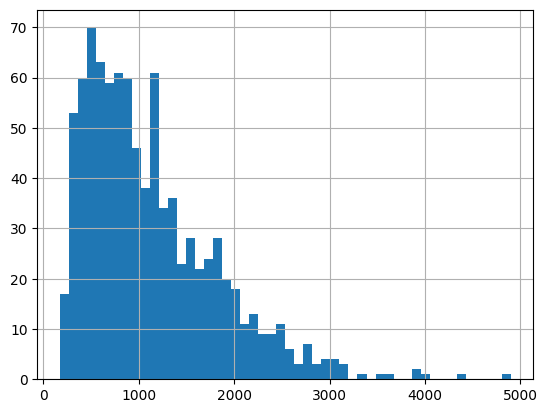

In [267]:
import matplotlib.pyplot as plt
portatiles['Price_euros'].hist(bins=50)

In [268]:
#Una técnica habitual en estos casos es transformar el target con logaritmo:
import numpy as np
y_log = np.log(portatiles['Price_euros'])